In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Parameters
N = 128                    # Number of grid points
L = 2 * np.pi              # Domain length
c = 1.0                    # Advection coefficient
nu = 0.1                   # Diffusion coefficient
dt = 0.01                  # Time step

In [3]:
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Wave numbers
k = np.fft.fftfreq(N, d=dx) * 2 * np.pi

# Initial condition
u0 = np.exp(-((x - np.pi)**2) / 0.5)


In [4]:
# to solve advection-diffusion using spectral method
def adv_difu_spect(u_i, t_f, dt, c, nu, k):

    u = u_i.copy()
    t = 0
    T_steps = int(t_f / dt)
    
    for _ in range(T_steps):
        u_h = np.fft.fft(u)
        
        # Apply spectral operators
        u_h = u_h * np.exp(-1j * c * k * dt - nu * k**2 * dt)
        
        # Transform back to physical
        u = np.fft.ifft(u_h).real
        t += dt

    return u


In [5]:
# for different time
times = [0, 2, 4, 10]
soln = {}

for t in times:
    if t == 0:
        soln[t] = u0
    else:
        soln[t] = adv_difu_spect(u0, t, dt, c, nu, k)
# print(soln)


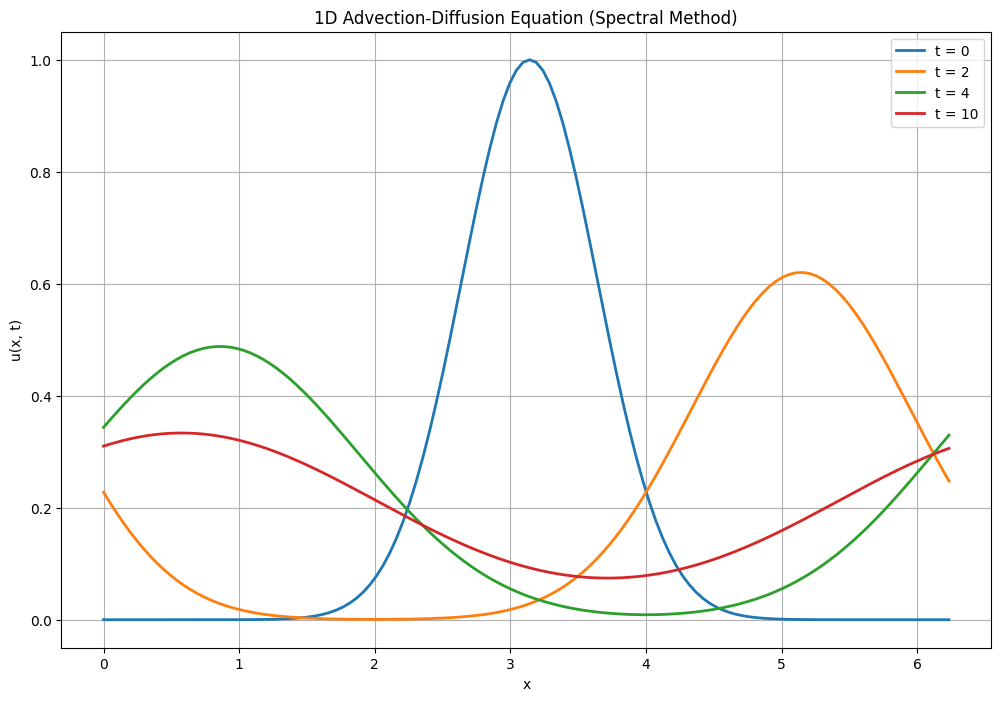

t = 0: max(u) = 1.0
t = 2: max(u) = 0.6200981467380939
t = 4: max(u) = 0.4878170943938097
t = 10: max(u) = 0.3334224858856688


In [6]:
# Plotting
plt.figure(figsize=(12, 8))

# Plot all solutions
for t in times:
    plt.plot(x, soln[t], linewidth=2, label=f't = {t}')

plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title('1D Advection-Diffusion Equation (Spectral Method)')
plt.legend()
plt.grid()
plt.show()

for t in times:
    print(f"t = {t}: max(u) = {np.max(soln[t])}")


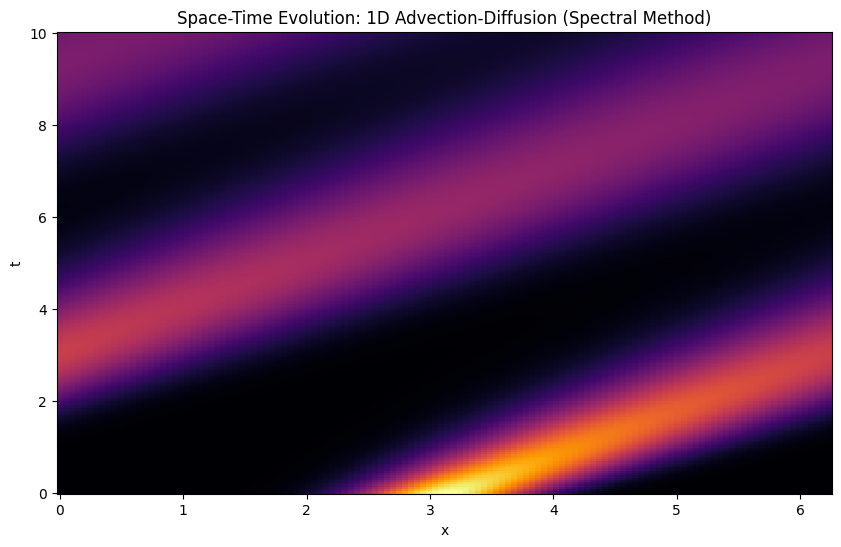

In [ ]:
t_sample = np.linspace(0, 10, 200)
U = np.zeros((len(t_sample), N))

for i, t in enumerate(t_sample):
    if t == 0:
        U[i] = u0
    else:
        U[i] = adv_difu_spect(u0, t, dt, c, nu, k)

# Space-time plot
plt.figure(figsize=(10, 6))
plt.pcolormesh(x, t_sample, U, shading='auto', cmap='inferno')
plt.colorbar(label='u(x, t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Space-Time Evolution: 1D Advection-Diffusion (Spectral Method)')
plt.show()
